# Peer-to-Peer Lending Platform Growth Analysis

**Objective:** Understand loan growth, funding patterns, borrower behaviour, loan purposes, risk grades, borrower locations and default rates of a Peer-to-Peer (P2P) lending platform.

**Tools used:** Python (Pandas, NumPy, Matplotlib, Seaborn)

**Flow:**
1. Load data from the MySQL database
2. Explore the raw data
3. Clean the data
4. Exploratory Data Analysis (EDA) with visualizations
5. Summarize key business insights
6. Export the cleaned data for the Power BI dashboard


#

## Import Libraries and Load Data from MySQL

Connection to the MySQL database using the `fetch_data_from_database()` function defined in `db_connection.py`. By running `db_connection.py` once to load the P2P lending CSV data into the database — here we simply read it back out for analysis.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from database_connection import fetch_data_from_database

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")


Libraries imported successfully.


In [17]:
df = fetch_data_from_database()

print("Shape of dataset (rows, columns):", df.shape)
print(df.head())


Shape of dataset (rows, columns): (2000, 16)
     Loan_ID  Issue_Date Borrower_City Employment_Type  Annual_Income_INR  \
0  P2P101175  2024-09-11     Bengaluru        Salaried            20000.0   
1  P2P101704  2024-02-29         Delhi        Salaried            71100.0   
2  P2P101493  2022-09-11         Delhi        Salaried            56900.0   
3  P2P101908  2023-06-26       Kolkata  Business Owner            64200.0   
4  P2P101759  2021-12-03        Jaipur        Salaried            57700.0   

         Loan_Purpose  Loan_Amount_INR  Funded_Amount_INR  Interest_Rate  \
0  Debt Consolidation         262500.0           236400.0          11.69   
1             Vehicle         133300.0           126400.0          11.01   
2             Wedding         149800.0           143500.0          10.60   
3    Home Improvement         140600.0           133200.0          11.24   
4    Home Improvement         240900.0           225600.0          11.95   

   Loan_Term_Months Risk_Grade Loan

#

## All Data Information

Before cleaning the data, understanding the structure, data types, missing values and duplicate records in the raw dataset.


In [18]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Loan_ID              2000 non-null   str    
 1   Issue_Date           2000 non-null   object 
 2   Borrower_City        2000 non-null   str    
 3   Employment_Type      2000 non-null   str    
 4   Annual_Income_INR    2000 non-null   float64
 5   Loan_Purpose         2000 non-null   str    
 6   Loan_Amount_INR      2000 non-null   float64
 7   Funded_Amount_INR    2000 non-null   float64
 8   Interest_Rate        2000 non-null   float64
 9   Loan_Term_Months     2000 non-null   int64  
 10  Risk_Grade           2000 non-null   str    
 11  Loan_Status          2000 non-null   str    
 12  Total_Repayment_INR  2000 non-null   float64
 13  Investor_Count       2000 non-null   int64  
 14  Income_Verification  2000 non-null   str    
 15  Loan_Channel         2000 non-null   str    
dtyp

In [19]:
print(df.describe())


       Annual_Income_INR  Loan_Amount_INR  Funded_Amount_INR  Interest_Rate  \
count        2000.000000     2.000000e+03       2.000000e+03    2000.000000   
mean        61249.750000     2.678295e+05       2.551153e+05      12.870520   
std         30507.874314     1.794830e+05       1.719193e+05       3.080449   
min         18000.000000     3.000000e+04       2.860000e+04       7.500000   
25%         39975.000000     1.444750e+05       1.374750e+05      10.610000   
50%         54400.000000     2.231500e+05       2.134500e+05      12.450000   
75%         75625.000000     3.336500e+05       3.180750e+05      14.570000   
max        269200.000000     1.500000e+06       1.469600e+06      23.680000   

       Loan_Term_Months  Total_Repayment_INR  Investor_Count  
count       2000.000000         2.000000e+03     2000.000000  
mean          32.262000         2.415150e+05        7.078000  
std           13.513203         2.013535e+05        5.023199  
min           12.000000         6.30

In [20]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
Loan_ID                0
Issue_Date             0
Borrower_City          0
Employment_Type        0
Annual_Income_INR      0
Loan_Purpose           0
Loan_Amount_INR        0
Funded_Amount_INR      0
Interest_Rate          0
Loan_Term_Months       0
Risk_Grade             0
Loan_Status            0
Total_Repayment_INR    0
Investor_Count         0
Income_Verification    0
Loan_Channel           0
dtype: int64


In [21]:
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


#

## Data Cleaning

The cleaning process prepares the P2P lending data for reliable analysis.

1. Convert `Issue_Date` to a proper date format.
2. Handle missing borrower city and employment type using `Unknown`.
3. Fill missing numeric values such as `Annual_Income_INR` and `Interest_Rate` using their median values.
4. Remove duplicate records.
5. Create a `Year` column from `Issue_Date` for time-based analysis.


In [22]:
print("Data types BEFORE cleaning:")
print(df.dtypes)


Data types BEFORE cleaning:
Loan_ID                    str
Issue_Date              object
Borrower_City              str
Employment_Type            str
Annual_Income_INR      float64
Loan_Purpose               str
Loan_Amount_INR        float64
Funded_Amount_INR      float64
Interest_Rate          float64
Loan_Term_Months         int64
Risk_Grade                 str
Loan_Status                str
Total_Repayment_INR    float64
Investor_Count           int64
Income_Verification        str
Loan_Channel               str
dtype: object


In [23]:
df['Issue_Date'] = pd.to_datetime(df['Issue_Date'], errors='coerce')

df['Borrower_City'] = df['Borrower_City'].fillna('Unknown')
df['Employment_Type'] = df['Employment_Type'].fillna('Unknown')

numeric_fill_cols = ['Annual_Income_INR', 'Interest_Rate']

for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

duplicate_count = df.duplicated().sum()
df = df.drop_duplicates()

df['Year'] = df['Issue_Date'].dt.year

print("Duplicate rows removed:", duplicate_count)
print("Shape after cleaning:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicate rows removed: 0
Shape after cleaning: (2000, 17)

Missing values after cleaning:
Loan_ID                0
Issue_Date             0
Borrower_City          0
Employment_Type        0
Annual_Income_INR      0
Loan_Purpose           0
Loan_Amount_INR        0
Funded_Amount_INR      0
Interest_Rate          0
Loan_Term_Months       0
Risk_Grade             0
Loan_Status            0
Total_Repayment_INR    0
Investor_Count         0
Income_Verification    0
Loan_Channel           0
Year                   0
dtype: int64


In [24]:
print("Data types AFTER cleaning:")
print(df.dtypes)


Data types AFTER cleaning:
Loan_ID                          str
Issue_Date             datetime64[s]
Borrower_City                    str
Employment_Type                  str
Annual_Income_INR            float64
Loan_Purpose                     str
Loan_Amount_INR              float64
Funded_Amount_INR            float64
Interest_Rate                float64
Loan_Term_Months               int64
Risk_Grade                       str
Loan_Status                      str
Total_Repayment_INR          float64
Investor_Count                 int64
Income_Verification              str
Loan_Channel                     str
Year                           int32
dtype: object


#

## Exploratory Data Analysis (EDA)

Data is cleaned. Now we explore lending growth, funding patterns, loan purposes, loan status, risk grades, borrower cities and default rates.


### 1. Loan Growth by Year


Loan Count by Year:
Year
2021    257
2022    317
2023    354
2024    488
2025    584
Name: Loan_ID, dtype: int64


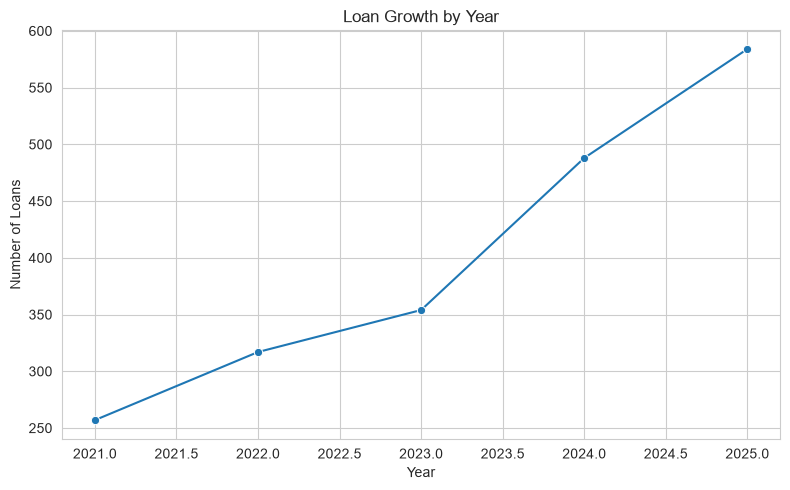

In [25]:
loan_growth = df.groupby('Year')['Loan_ID'].count()

print("Loan Count by Year:")
print(loan_growth)

plt.figure(figsize=(8, 5))
sns.lineplot(x=loan_growth.index, y=loan_growth.values, marker='o')
plt.title('Loan Growth by Year')
plt.xlabel('Year')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()


### 2. Funding by Loan Purpose


Funding by Loan Purpose:
Loan_Purpose
Debt Consolidation    158289300.0
Home Improvement       75000300.0
Small Business         68148300.0
Education              61833200.0
Vehicle                53554200.0
Medical                35809900.0
Travel                 29758400.0
Wedding                27837000.0
Name: Funded_Amount_INR, dtype: float64


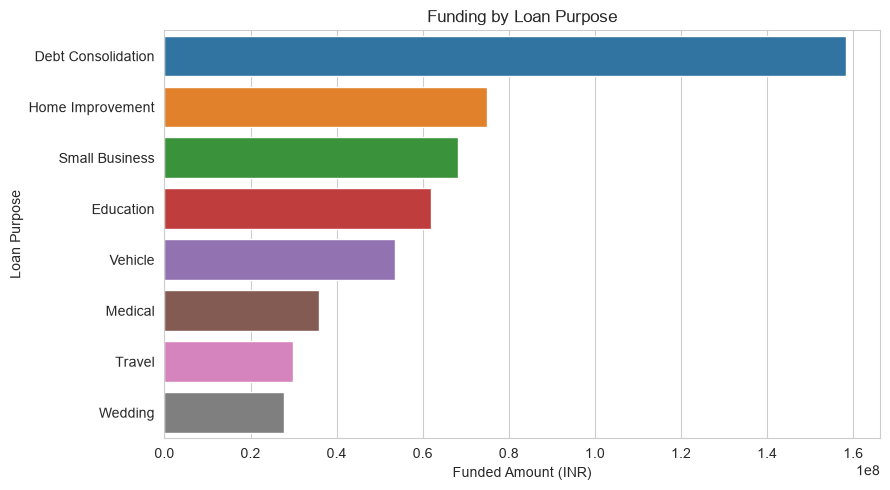

In [26]:
funding_by_purpose = (
    df.groupby('Loan_Purpose')['Funded_Amount_INR']
    .sum()
    .sort_values(ascending=False)
)

print("Funding by Loan Purpose:")
print(funding_by_purpose)

plt.figure(figsize=(9, 5))
sns.barplot(x=funding_by_purpose.values, y=funding_by_purpose.index,
            hue=funding_by_purpose.index, legend=False)
plt.title('Funding by Loan Purpose')
plt.xlabel('Funded Amount (INR)')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()


### 3. Loan Status Distribution


Loan Status:
Loan_Status
Completed    1029
Active        756
Late          130
Defaulted      85
Name: count, dtype: int64


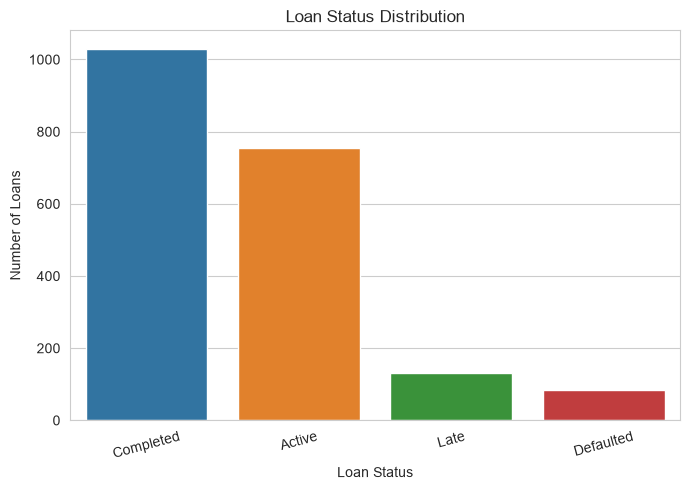

In [27]:
loan_status = df['Loan_Status'].value_counts()

print("Loan Status:")
print(loan_status)

plt.figure(figsize=(7, 5))
sns.barplot(x=loan_status.index, y=loan_status.values,
            hue=loan_status.index, legend=False)
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 4. Risk Grade Distribution


Risk Grade:
Risk_Grade
A    429
B    675
C    570
D    235
E     91
Name: count, dtype: int64


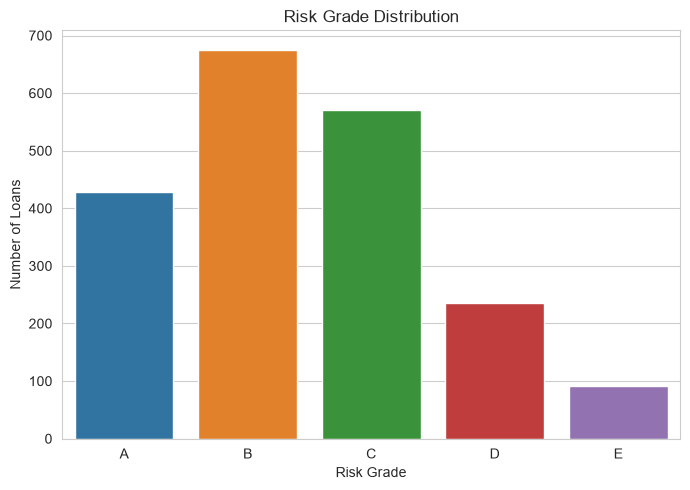

In [28]:
risk_grade = df['Risk_Grade'].value_counts().sort_index()

print("Risk Grade:")
print(risk_grade)

plt.figure(figsize=(7, 5))
sns.barplot(x=risk_grade.index, y=risk_grade.values,
            hue=risk_grade.index, legend=False)
plt.title('Risk Grade Distribution')
plt.xlabel('Risk Grade')
plt.ylabel('Number of Loans')
plt.tight_layout()
plt.show()


### 5. Funding by Borrower City


Funding by Borrower City:
Borrower_City
Bengaluru    81014000.0
Mumbai       76368000.0
Hyderabad    63322300.0
Delhi        61255900.0
Pune         52414200.0
Chennai      41968300.0
Kolkata      35753900.0
Jaipur       35342700.0
Ahmedabad    29807300.0
Lucknow      27672000.0
Unknown       5312000.0
Name: Funded_Amount_INR, dtype: float64


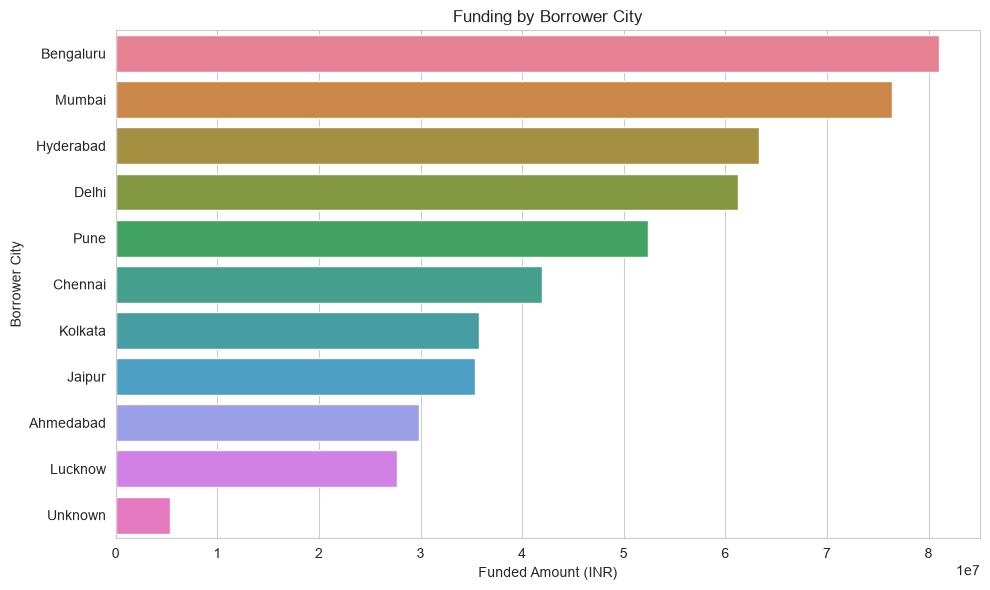

In [29]:
funding_by_city = (
    df.groupby('Borrower_City')['Funded_Amount_INR']
    .sum()
    .sort_values(ascending=False)
)

print("Funding by Borrower City:")
print(funding_by_city)

plt.figure(figsize=(10, 6))
sns.barplot(x=funding_by_city.values, y=funding_by_city.index,
            hue=funding_by_city.index, legend=False)
plt.title('Funding by Borrower City')
plt.xlabel('Funded Amount (INR)')
plt.ylabel('Borrower City')
plt.tight_layout()
plt.show()


### 6. Default Rate by Risk Grade


Default Rate by Risk Grade (%):
Risk_Grade
A     1.40
B     2.22
C     5.09
D     8.51
E    16.48
Name: Loan_Status, dtype: float64


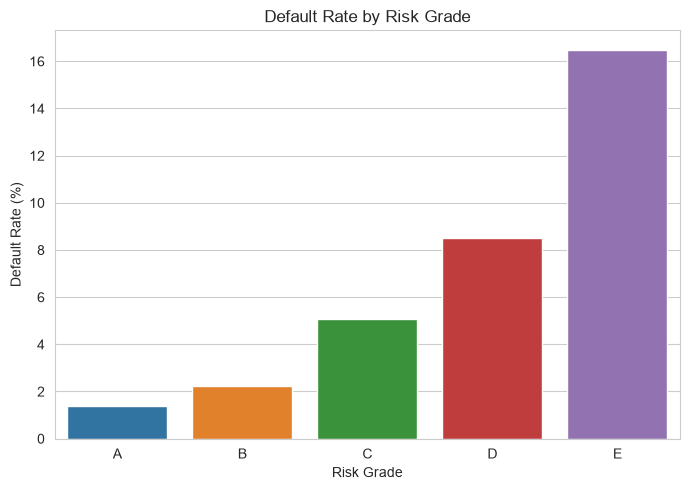

In [30]:
default_by_risk = (
    df.groupby('Risk_Grade')['Loan_Status']
    .apply(lambda x: (x == 'Defaulted').mean() * 100)
    .sort_index()
)

print("Default Rate by Risk Grade (%):")
print(default_by_risk.round(2))

plt.figure(figsize=(7, 5))
sns.barplot(x=default_by_risk.index, y=default_by_risk.values,
            hue=default_by_risk.index, legend=False)
plt.title('Default Rate by Risk Grade')
plt.xlabel('Risk Grade')
plt.ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()


#

## Key Insights Summary

The following section calculates the main business indicators directly from the cleaned dataset. This keeps the insights aligned with the actual data rather than hard-coding values.


In [31]:
total_loans = len(df)
total_funded = df['Funded_Amount_INR'].sum()
average_loan = df['Loan_Amount_INR'].mean()
average_funded = df['Funded_Amount_INR'].mean()
default_rate = (df['Loan_Status'] == 'Defaulted').mean() * 100

top_purpose = df['Loan_Purpose'].value_counts().idxmax()
top_status = df['Loan_Status'].value_counts().idxmax()
top_risk_grade = df['Risk_Grade'].value_counts().idxmax()
top_city = df.groupby('Borrower_City')['Funded_Amount_INR'].sum().idxmax()

print("Business Insights")
print(f"1. Total loans after cleaning: {total_loans:,}")
print(f"2. Total funded amount: Rs. {total_funded:,.2f}")
print(f"3. Average loan amount: Rs. {average_loan:,.2f}")
print(f"4. Average funded amount per loan: Rs. {average_funded:,.2f}")
print(f"5. Most common loan purpose: {top_purpose}")
print(f"6. Largest loan status category: {top_status}")
print(f"7. Most common risk grade: {top_risk_grade}")
print(f"8. Overall default rate: {default_rate:.2f}%")
print(f"9. City receiving the highest total funding: {top_city}")


Business Insights
1. Total loans after cleaning: 2,000
2. Total funded amount: Rs. 510,230,600.00
3. Average loan amount: Rs. 267,829.55
4. Average funded amount per loan: Rs. 255,115.30
5. Most common loan purpose: Debt Consolidation
6. Largest loan status category: Completed
7. Most common risk grade: B
8. Overall default rate: 4.25%
9. City receiving the highest total funding: Bengaluru


#

## Export Cleaned Data for Power BI

The cleaned dataset is exported so the same cleaned data can be reused for the Power BI dashboard and SQL analysis.


In [32]:
df.to_csv('cleaned_p2p_lending_data.csv', index=False)

print("Cleaned data exported successfully as 'cleaned_p2p_lending_data.csv'")
print("Final shape:", df.shape)


Cleaned data exported successfully as 'cleaned_p2p_lending_data.csv'
Final shape: (2000, 17)


#

## Conclusion

The notebook follows the same workflow as the e-commerce analysis:

- Data is loaded from MySQL through `db_connection.py`.
- The raw dataset is inspected before cleaning.
- Missing values, duplicate records and date fields are handled.
- EDA is performed using business-focused tables and visualizations.
- Key lending, funding, risk and default indicators are calculated.
- The cleaned dataset is exported for Power BI and further analysis.
